In [1]:
import numpy as np, camb, local, importlib
from matplotlib.pyplot import *

In [2]:
importlib.reload(local)

<module 'local' from '/global/u1/t/toshiyan/Work/Ongoing/rotation/pmf-bispec/local.py'>

In [3]:
# --- CAMB calculation ---
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
lmax = 2000
pars.set_for_lmax(lmax, lens_potential_accuracy=0)
# for all ell, pars.Accuracy.lSampleBoost = 50
data = camb.get_transfer_functions(pars)
results = camb.get_results(pars)
eta0 = results.conformal_time(0)

In [4]:
k_arr = np.logspace(-5,-1.5,1000)

In [5]:
eta_list = np.logspace(1, 4, 100)
back_ev_org = data.get_background_time_evolution(eta_list, ['visibility'])

In [6]:
eta_dec = eta_list[np.argmax(back_ev_org['visibility'])]
print(eta_dec)

284.8035868435802


In [54]:
eta = np.logspace(np.log10(eta_dec), 4, 200)
back_ev = data.get_background_time_evolution(eta, ['x_e', 'visibility', 'dopacity', 'opacity'])

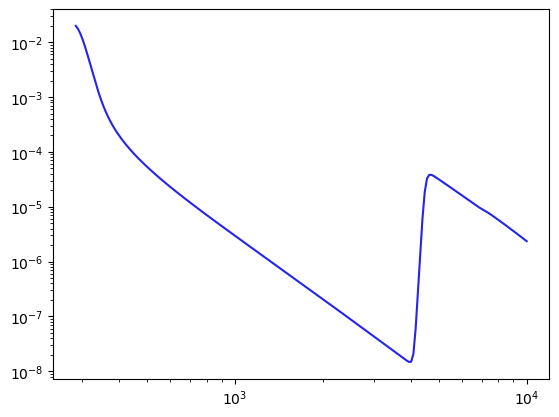

In [55]:
loglog(eta, back_ev['visibility'])

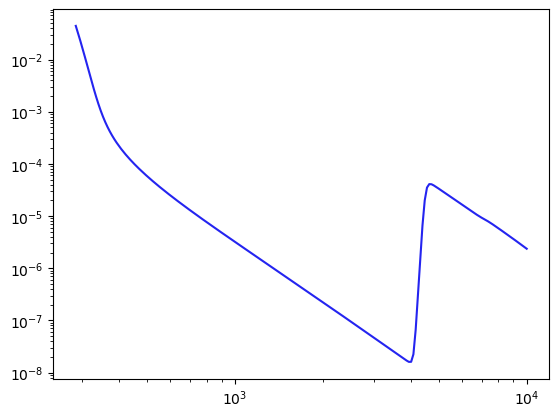

In [56]:
loglog(eta, back_ev['opacity'])

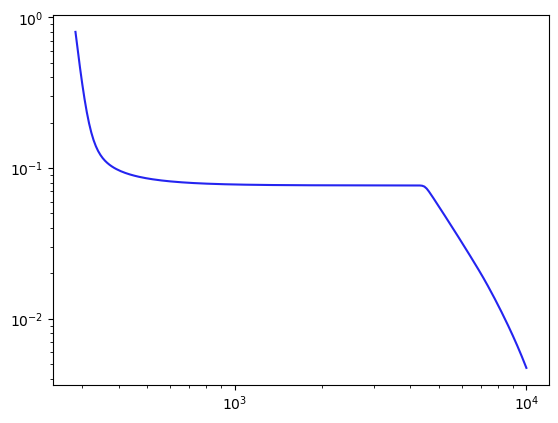

In [57]:
# optical depth from eta_0 to \eta
loglog(eta, np.log(back_ev['opacity']/back_ev['visibility']))

In [58]:
integ, integ0 = local.integ_opacity(100, k_arr, eta0, eta, back_ev['opacity'])

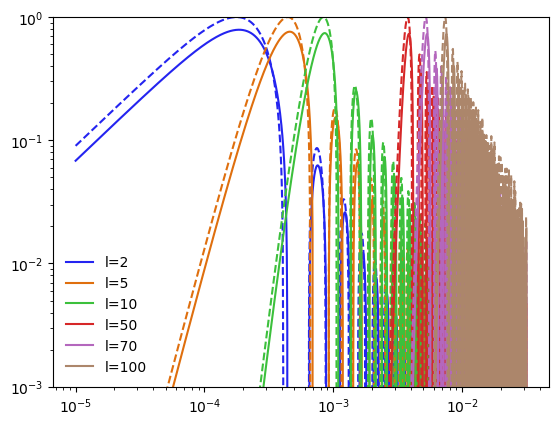

In [62]:
xscale('log')
yscale('log')
ylim(1e-3,1)
for l in [2,5,10,50,70,100]:
    norm = np.max(integ0[l])
    line, = plot(k_arr, integ[l] / norm, label=f'l={l}')
    plot(k_arr, integ0[l] / norm, ls='--', color=line.get_color())
legend()